In [141]:
import cv2
import matplotlib.patches
import matplotlib.pyplot as plt
import os
import numpy as np
from pathlib import Path

In [142]:
data_folder = os.path.join(os.getcwd(), "dados")


In [14]:
i = 1

for img in os.listdir(data_folder):
    if img.endswith(".jpg"):
        print("ok!")

ok!
ok!
ok!
ok!


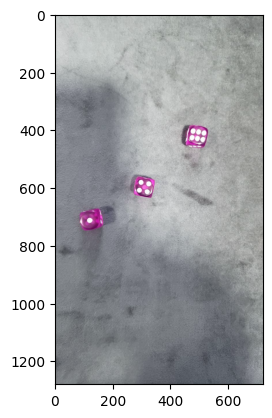

In [448]:
img = cv2.imread(data_folder + "/" + "img1.jpg")
plt.imshow(img)

In [449]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


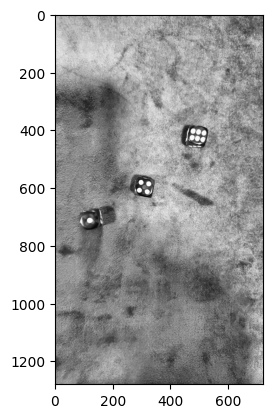

In [450]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_equ = clahe.apply(img_gray)
plt.imshow(img_equ, cmap = "gray")

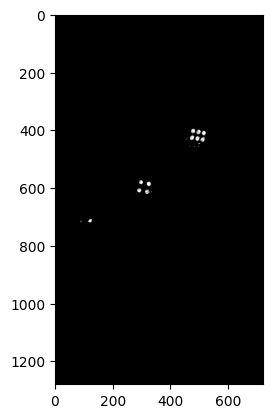

In [451]:

_,img_binaria = cv2.threshold(img_gray,250,255, cv2.THRESH_TOZERO)

plt.imshow(img_binaria, cmap = "grey")

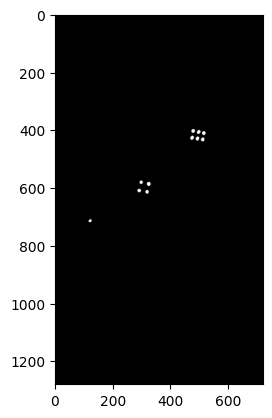

In [452]:
img_filtrada = cv2.medianBlur(img_binaria, 7)
plt.imshow(img_filtrada, cmap = "gray")

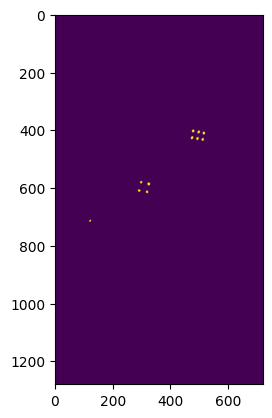

In [453]:
elipses = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))

erodir = cv2.erode(img_filtrada, elipses, iterations = 2)

plt.imshow(erodir)

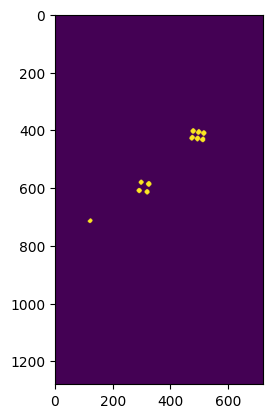

In [454]:
dilatar = cv2.dilate(erodir, elipses, iterations = 5)
plt.imshow(dilatar)

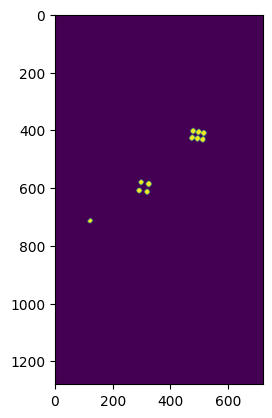

In [455]:
img_filtrada = cv2.GaussianBlur(dilatar, (5,5), 0)
plt.imshow(img_filtrada)

In [456]:
pips = cv2.HoughCircles(img_filtrada, cv2.HOUGH_GRADIENT, dp = 1, minDist=2, param1=30, param2=17, minRadius=5, maxRadius=50)
pipscont = np.round(pips[0, :]).astype("int")
len(pipscont)

20

In [457]:
from itertools import product

ground_truth = {"img1.jpg": 11, "img2.jpg": 4, "img3.jpg": 15, "img4.jpg": 7}

def preprocess(img_path):
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_binaria = cv2.threshold(img_gray, 250, 255, cv2.THRESH_TOZERO)
    img_filtrada = cv2.medianBlur(img_binaria, 7)
    elipses = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    erodir = cv2.erode(img_filtrada, elipses, iterations=2)
    dilatar = cv2.dilate(erodir, elipses, iterations=3)
    return img, dilatar

def count_circles(proc, dp, minDist, param1, param2, minRadius, maxRadius):
    pips = cv2.HoughCircles(proc, cv2.HOUGH_GRADIENT, dp=dp, minDist=minDist,
                            param1=param1, param2=param2,
                            minRadius=minRadius, maxRadius=maxRadius)
    return len(pips[0]) if pips is not None else 0

# Preprocess all images once
preprocessed_imgs = {
    name: preprocess(os.path.join(data_folder, name))
    for name in ground_truth
}

# Grid search
param_grid = {
    "dp":        [1],
    "minDist":   [3, 5, 8, 12],
    "param1":    [5, 10, 15],
    "param2":    list(range(4, 25)),
    "minRadius": [1, 3, 5],
    "maxRadius": [20, 30, 40, 50],
}

keys = list(param_grid.keys())
best_params, best_score = None, -1

for combo in product(*param_grid.values()):
    params = dict(zip(keys, combo))
    score = sum(
        count_circles(proc, **params) == ground_truth[name]
        for name, (_, proc) in preprocessed_imgs.items()
    )
    if score > best_score:
        best_score, best_params = score, params
    if best_score == len(ground_truth):
        break

print(f"Best score: {best_score}/{len(ground_truth)}")
print(f"Best params: {best_params}")
for name, (_, proc) in preprocessed_imgs.items():
    n = count_circles(proc, **best_params)
    gt = ground_truth[name]
    status = "✓" if n == gt else "✗"
    print(f"  {status} {name}: detected={n}, expected={gt}")

Best score: 4/4
Best params: {'dp': 1, 'minDist': 8, 'param1': 10, 'param2': 9, 'minRadius': 1, 'maxRadius': 20}
  ✓ img1.jpg: detected=11, expected=11
  ✓ img2.jpg: detected=4, expected=4
  ✓ img3.jpg: detected=15, expected=15
  ✓ img4.jpg: detected=7, expected=7


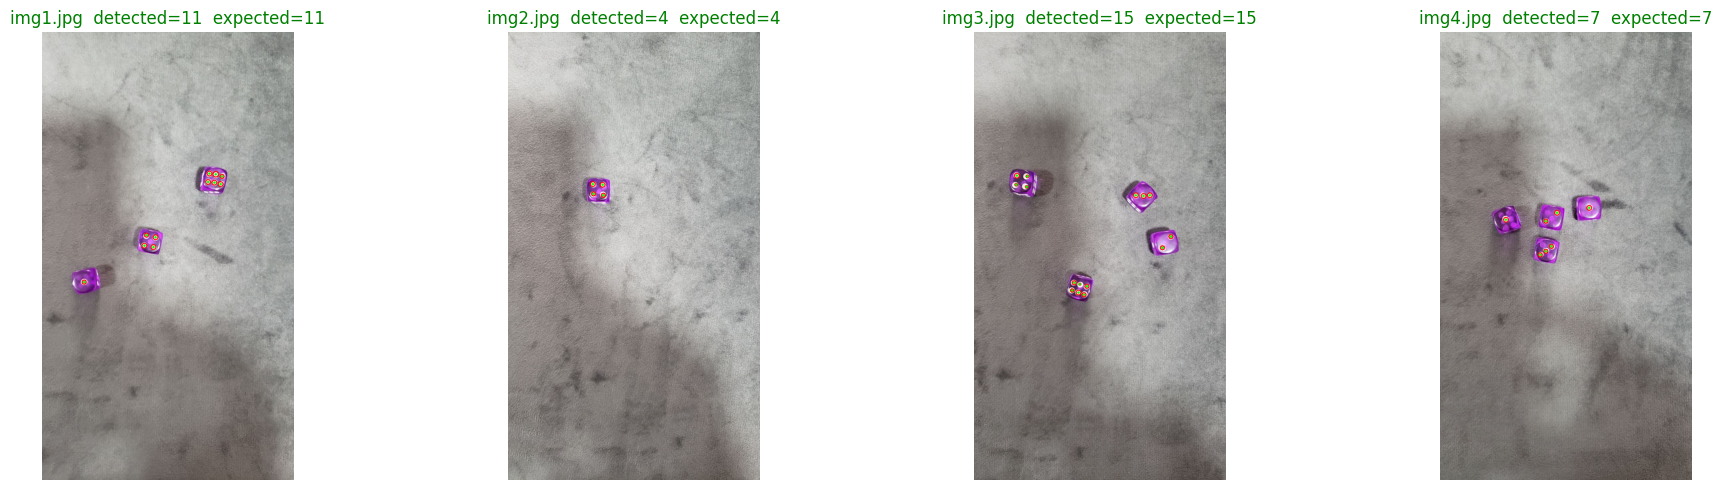

In [458]:
# Visualize all 4 images with detected circles using best params
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, (orig, proc)) in zip(axes, preprocessed_imgs.items()):
    display = cv2.cvtColor(orig.copy(), cv2.COLOR_BGR2RGB)
    pips = cv2.HoughCircles(proc, cv2.HOUGH_GRADIENT, **best_params)
    if pips is not None:
        for x, y, r in np.round(pips[0]).astype("int"):
            cv2.circle(display, (x, y), r, (255, 0, 0), 2)
            cv2.circle(display, (x, y), 2, (0, 255, 0), 3)
    n = len(pips[0]) if pips is not None else 0
    gt = ground_truth[name]
    ax.imshow(display)
    ax.set_title(f"{name}  detected={n}  expected={gt}", color="green" if n == gt else "red")
    ax.axis("off")

plt.tight_layout()
plt.show()